In [1]:
import os
os.environ["JAX_MPS_ASYNC_DISPATCH"]="1"

In [2]:
import jax

from jax import numpy as jnp

import numpy as np

import scipy

from matplotlib import pyplot as plt
from matplotlib import patches as patches
from matplotlib import cm

import copy
import time
import datetime

In [3]:
key = jax.random.key(0)

dtype = jnp.float32

Platform 'mps' is experimental and not all JAX functionality may be correctly supported!
[jax-mps] JAX_MPS_ASYNC_DISPATCH is ON: async dispatch enabled — may be much faster, but experimental and may break. Unset it for safe synchronous execution.


In [4]:
T_R     = 4e5  # temperature of random agent (K)
T_C     = 2e6  # temperature of causal agent (K)
TAU     = 10.  # simulation time horizon (seconds)
EPSILON = .025 # timesteps (seconds)

NUM_ROLLOUTS = 10_000_000

CHUNK_SIZE = 1000

In [5]:
M     = 1e-21                               # mass (kg)
L     = 400                                 # length (meters) 
Q_MIN = jnp.array([0. , 0.  ], dtype=dtype) # minimum box displacements
Q_MAX = jnp.array([L  , L/5.], dtype=dtype) # maximum box displacements

def step_p(p, f):
    p     = f * EPSILON
    p_max = M * jnp.abs(Q_MAX - Q_MIN) / EPSILON
    new_p = jnp.sign(p) * jnp.minimum(p_max, jnp.abs(p))
    return new_p

def step_q(q, p, new_p):
    new_q = q  +  .5 * EPSILON * (p + new_p) / M
    return new_q

def enforce_elastic_collisions(p, q):
    q  = jnp.maximum(q, 2 * Q_MIN - q)
    p *= jnp.sign(q - Q_MIN)
    q  = jnp.minimum(q, 2 * Q_MAX - q)
    p *= jnp.sign(Q_MAX - q)
    return p, q

def step_phase_space(p, q, f):
    new_p        = step_p(p, f)
    new_q        = step_q(q, p, new_p)
    new_p, new_q = enforce_elastic_collisions(new_p, new_q)
    return new_p, new_q

In [6]:
timesteps = int(TAU / EPSILON)

In [7]:
def generate_fs(num_samples, key):
    # scale calculation formula from https://math.stackexchange.com/a/1426406
    noise  = jax.random.normal(key, shape=(num_samples, 2), dtype=dtype)
    noise *= np.sqrt(M * scipy.constants.Boltzmann * T_R) / EPSILON
    return noise

def rollouts(p, q, key):
    """
    paths.shape = (timesteps, num_samples, q_dim)
    """
    ps = jnp.tile(p[None, :], (NUM_ROLLOUTS, 1))
    qs = jnp.tile(q[None, :], (NUM_ROLLOUTS, 1))

    paths = copy.deepcopy(qs[None, :])

    key, subkey = jax.random.split(key)
    fs          = generate_fs(NUM_ROLLOUTS, subkey)
    first_fs    = copy.deepcopy(fs)
    
    for i in range(timesteps):
        ps, qs      = step_phase_space(ps, qs, fs)
        paths       = jnp.append(paths, qs[None, :], axis=0)
        key, subkey = jax.random.split(key)
        fs          = generate_fs(NUM_ROLLOUTS, subkey)

    return paths, first_fs

In [8]:
# The following code is modified from 
# [1]: https://github.com/scipy/scipy/blob/main/scipy/stats/_kde.py
# [2]: https://github.com/scipy/scipy/blob/main/scipy/stats/_stats.pyx#L744
# [3]: code generated by Google Gemini Flash 3.6 to implement gaussian kde
# with diagonal bandwidth matrix (the idea to use a diagonal kernel was also
# suggested by Google Gemini Flash 3.6)
# 
# [1] has a copyright notice which I have reproduced below
# 
# -------------------------------------------------------------------------------
#
#  Define classes for (uni/multi)-variate kernel density estimation.
#
#  Currently, only Gaussian kernels are implemented.
#
#  Written by: Robert Kern
#
#  Date: 2004-08-09
#
#  Modified: 2005-02-10 by Robert Kern.
#              Contributed to SciPy
#            2005-10-07 by Robert Kern.
#              Some fixes to match the new scipy_core
#
#  Copyright 2004-2005 by Enthought, Inc.
#
# -------------------------------------------------------------------------------


def diag_gaussian_kde_logpdfs(dataset, subsampling=True, chunk_size=CHUNK_SIZE):
    d, m = dataset.shape
    
    std_per_dim = jnp.std(dataset, axis=1, keepdims=True)
    scotts_factor = jnp.power(m, -1. / (d + 4))
    diag_bandwidth = std_per_dim * scotts_factor  # shape (d, 1)
    dataset_ = (dataset / diag_bandwidth).T.astype(dtype)

    log_pdfs = jnp.zeros(m)
    for j in range(0, m, chunk_size):
        arg = jnp.sum((dataset_ - dataset_[j : j+chunk_size][:, None]) ** 2., axis=-1)
        log_pdfs.at[j : j+chunk_size].set(jax.scipy.special.logsumexp(-arg/2.))
    
    return log_pdfs

In [9]:
def log_vol_fracs(dataset):
    dataset = dataset.transpose((2, 0, 1)).reshape(-1, NUM_ROLLOUTS).astype(dtype)
    
    log_pdfs = diag_gaussian_kde_logpdfs(dataset)
    log_omega = -log_pdfs
    log_volume_fracs = log_omega - jax.scipy.special.logsumexp(log_omega)
    return log_volume_fracs

In [10]:
def entropic_force(p, q, key):
    paths, fs = rollouts(p, q, key)
    return jnp.mean( fs * log_vol_fracs(paths)[:, None] , axis=0 )

In [11]:
@jax.jit
def step_macrostate(p, q, key):
    key, subkey = jax.random.split(key)
    f_c  = 2. * T_C / T_R * entropic_force(p, q, subkey)
    p, q = step_phase_space(p, q, f_c)
    return p, q, key

In [12]:
p = jnp.array([0.   , 0.   ])
q = jnp.array([L/10., L/10.])

path = copy.deepcopy(q[None, :])

start_time = time.time()
for timestep in range(100):
    elapsed_time = time.time() - start_time
    print(timestep, datetime.timedelta(seconds=int(elapsed_time)), q)

    p, q, key = step_macrostate(p, q, key)
    path = jnp.append(path, q[None, :], axis=0)

0 0:00:00 [40. 40.]
1 0:00:40 [40.011444 39.99722 ]
2 0:00:40 [40.016453 39.97763 ]
3 0:00:40 [39.995068 39.951313]
4 0:00:40 [39.99132 39.91303]
5 0:00:41 [40.00494  39.858624]
6 0:00:41 [40.01616 39.86261]
7 0:00:41 [40.066135 39.89266 ]
8 0:00:41 [40.08935  39.882248]
9 0:00:41 [40.095695 39.858913]
10 0:00:41 [40.135254 39.854977]
11 0:00:41 [40.1294  39.87028]
12 0:00:41 [40.13497  39.893253]
13 0:00:41 [40.181282 39.910534]
14 0:00:41 [40.23122  39.905132]
15 0:00:41 [40.250885 39.89898 ]
16 0:00:41 [40.24494 39.88861]
17 0:00:42 [40.240273 39.86566 ]
18 0:00:42 [40.237984 39.854088]
19 0:00:42 [40.267685 39.865116]
20 0:00:42 [40.306953 39.86114 ]
21 0:00:42 [40.33329  39.863842]
22 0:00:42 [40.32169  39.870525]
23 0:00:42 [40.29946  39.858486]
24 0:00:42 [40.277725 39.85977 ]
25 0:00:42 [40.27016  39.838417]
26 0:00:42 [40.28827  39.811455]
27 0:00:42 [40.308975 39.799213]
28 0:00:43 [40.3505   39.777348]
29 0:00:43 [40.40666  39.747368]
30 0:00:43 [40.44832  39.712467]
31 0:00

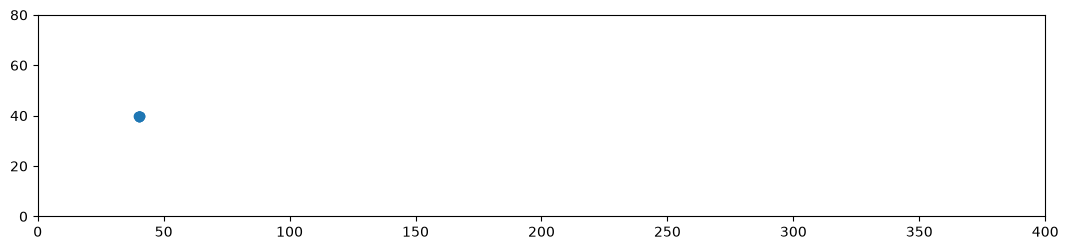

In [13]:
fig, ax = plt.subplots(figsize=(13, 13))
ax.scatter(*path[::10].T)
ax.set_xlim(Q_MIN[0], Q_MAX[0])
ax.set_ylim(Q_MIN[1], Q_MAX[1])
ax.set(aspect='equal')
plt.show()